# -------------------------------------- PySpark    -----------------------------------------

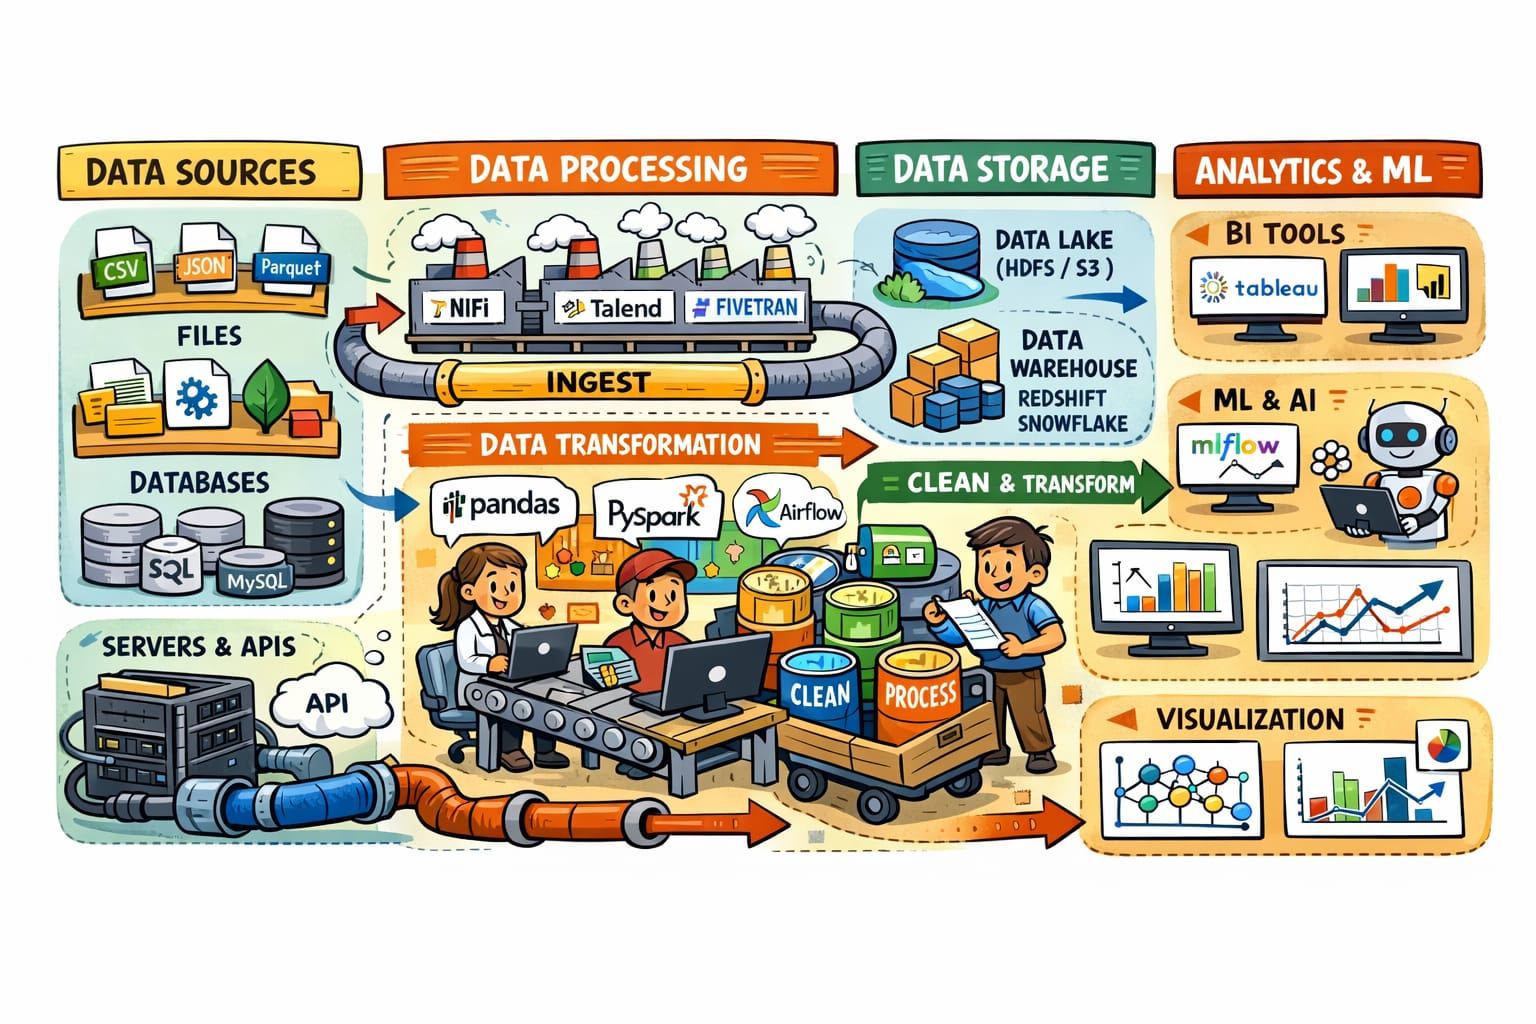

## Apache Hadoop

In [ ]:
Hadoop is an open-source big data ecosystem used to store and process very large datasets across multiple computers
using distributed storage and parallel processing.

                ┌──────────────────────────┐
                │        Hadoop             │
                │     (Ecosystem)           │
                └──────────────────────────┘
                             │
        ┌────────────────────┼────────────────────┐
        │                    │                    │
        ▼                    ▼                    ▼

┌───────────────┐    ┌───────────────┐    ┌────────────────┐
│     HDFS      │    │     YARN      │    │   MapReduce  <<<<<<<<<<<<<<< execution engine()
│ (Storage)     │    │ (Resource     │    │ (Processing)  │
│               │    │  Manager)     │    │               │
│ • Stores big  │    │ • Allocates   │    │ • Batch jobs  │
│   files       │    │   CPU & RAM   │    │ • Disk-based  │
│ • Distributed │    │ • Schedules   │    │ • Slower      │
│ • Fault-toler │    │   jobs        │    │ • Legacy      │
└───────────────┘    └───────────────┘    └────────────────┘


In [ ]:
Hadoop is an older ecosystem, Databricks is a newer ecosystem used today, 
and Spark is an execution engine like MapReduce — but more powerful.

| MapReduce    | Spark             |
| ------------ | ----------------- |

| Old          | Modern            |
| Disk-based   | In-memory (RAM ) 📌 This type of computation makes Spark 10–100× faster.
| Batch only   | Batch + Streaming data✅
| Slow         | Fast              |
| Hard to code | Easy              |

Spark processes big data much faster than MapReduce because it keeps data in RAM instead of writing to disk after every step.
spark Writes to disk only when needed 

pandas vs spark

| Feature         | Pandas              | Spark                       |
| --------------- | ------------------- | --------------------------- |
| Data size       | Small / medium      | **Very large (TBs)**        |
| Runs on         | One machine         | **Cluster (many machines)** |
| Memory          | Single RAM          | **Distributed RAM**         |
| Speed           | Fast for small data | Fast for big data           |
| Fault tolerance | ❌ No                | **✅ Yes**                   |
| Parallelism     | Limited             | **High**                    |


## Databricks

In [ ]:
Databricks is a unified cloud data platform built on Apache Spark for big data processing, analytics, and machine learning.

                ┌─────────────────────────────┐
                │         Databricks           │
                │         Ecosystem            │
                └─────────────────────────────┘
                               │
        ┌──────────────────────┼────────────────────────┐
        │                      │                        │
        ▼                      ▼                        ▼

┌───────────────┐    ┌───────────────────┐    ┌──────────────────┐
│ Cloud Storage │    │   Delta Lake      │    │   MLflow         │
│ (S3  /ADLS/GCS)    │ (ACID + Schema)   │    │ (ML Lifecycle)   │
│               │    │                   │    │                  │
└───────────────┘    └───────────────────┘    └──────────────────┘
        │
        ▼
┌────────────────────────────────────────────────────────┐
│                  Apache Spark Engine<<<<<<<<<<<<<<<<<<<<<<<<execution engine()            
│   • Batch Processing                                   │
│   • Streaming                                          │
│   • SQL Analytics                                      │
│   • Machine Learning                                   │
└────────────────────────────────────────────────────────┘
        │
        ▼
┌────────────────────────────────────────────────────────┐
│        Databricks Runtime + Job Scheduler               │
│   • Optimized Spark                                    │
│   • Auto-scaling                                       │
│   • Workflow Automation                                │
└────────────────────────────────────────────────────────┘
        │
        ▼
┌────────────────────────────────────────────────────────┐
│            Databricks Notebooks / Workspace             │
│      (Python | SQL | Scala | R)                         │
└────────────────────────────────────────────────────────┘


## Apache Spark

In [ ]:
Spark is an open-source, distributed data processing engine used to process large datasets quickly 
by performing computations in memory(RAM) across a cluster of computers.

Spark is written in Scala(Used in core Spark development)

Spark is fault-tolerant and supports streaming because it uses in-memory RDDs with lineage for recovery 
and executes tasks in parallel across worker nodes managed by a cluster manager(YARN, Kubernetes)


RDD (Resilient Distributed Dataset) is an immutable,RDD is a way Spark stores and 
processes data across many computers in memory so it runs fast and can recover from failures.

In [ ]:
Apache Spark एक open-source distributed data processing engine है, 
जिसका उपयोग बहुत बड़े डेटा (Big Data) को तेज़ी से प्रोसेस करने के लिए किया जाता है।
In-memory computation की वजह से तेज़ processing
Fault-tolerant → अगर कोई node fail हो जाए तो data दुबारा बन जाता है
Scalable → छोटे से लेकर बहुत बड़े cluster पर काम करता है
Multiple languages → Python (PySpark), Scala, SQL, Java


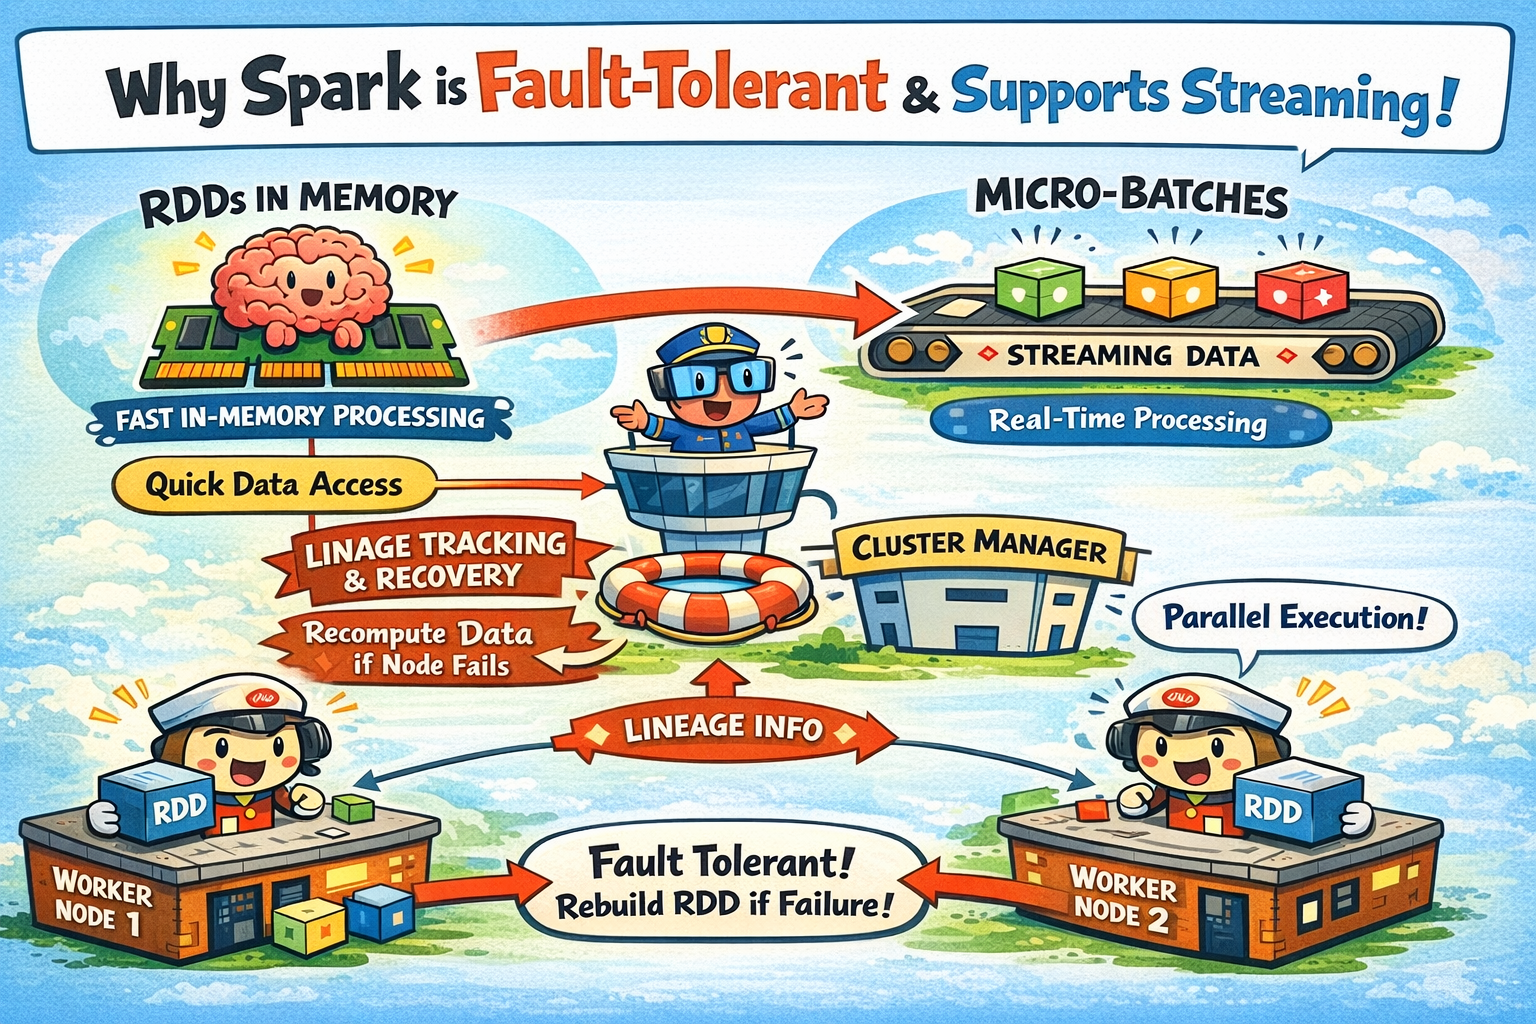

In [4]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\SURAJ\Downloads\Apache Spark's fault tolerance explained.png", width=00))


## PySpark

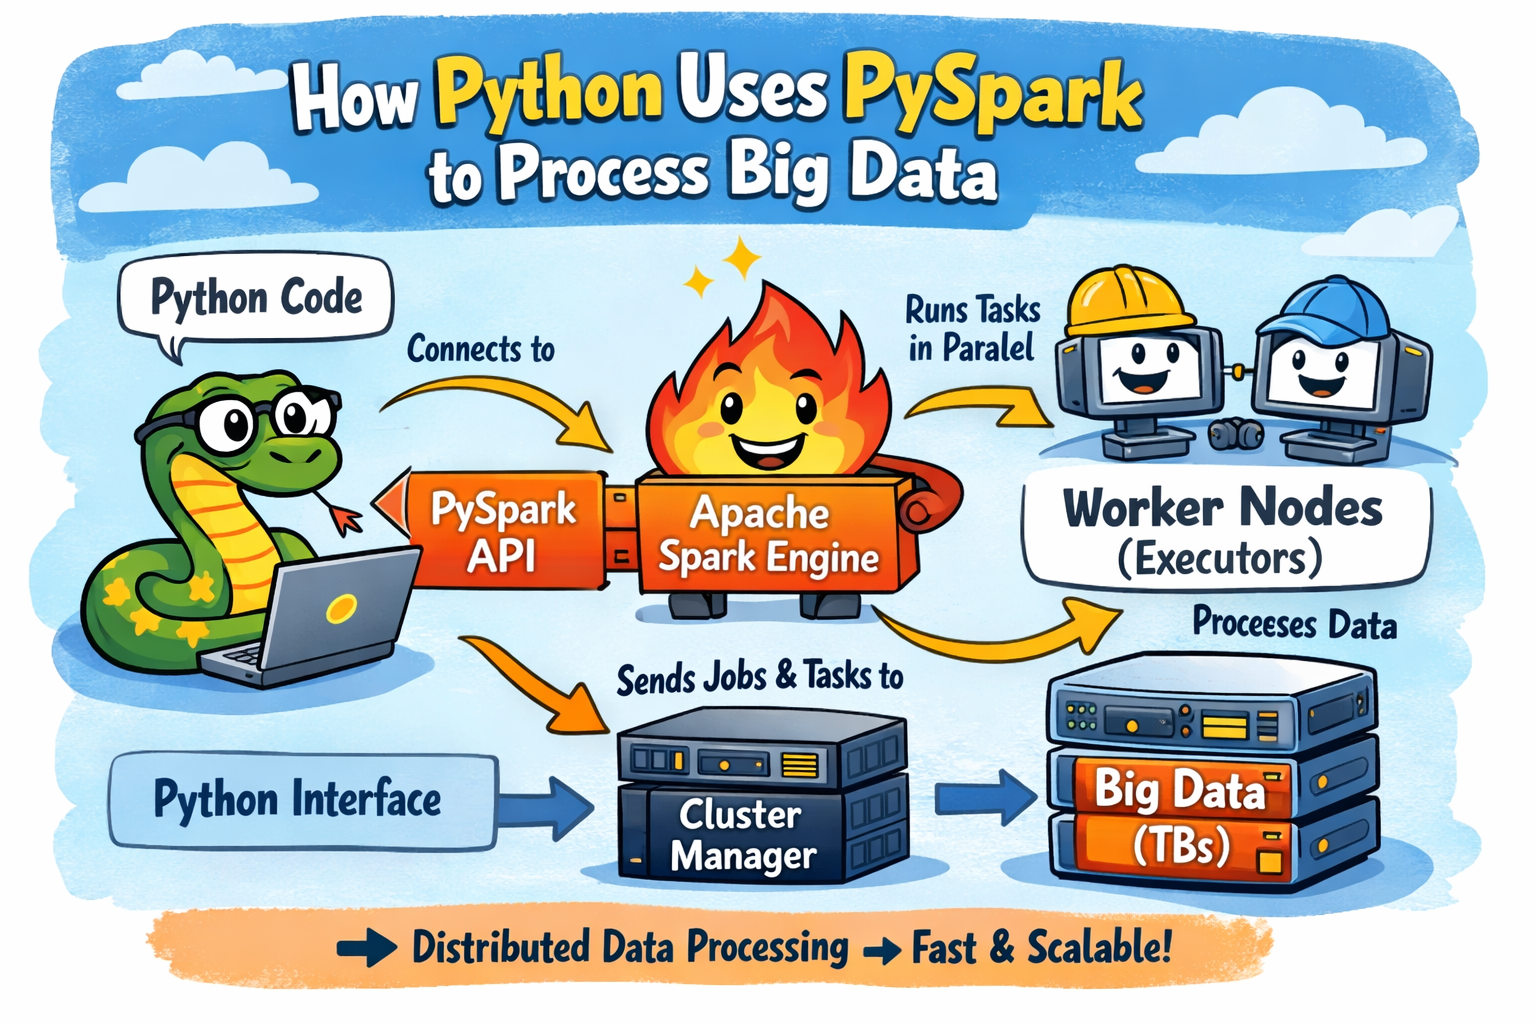

In [5]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\SURAJ\Downloads\ChatGPT Image Jan 27, 2026, 09_31_22 PM.png", width=800))


In [ ]:
PySpark is the Python API for Apache Spark.
PySpark lets you write Spark programs using Python, instead of Java or Scala, while still getting Spark’s speed and scalability.
It allows you to use Apache Spark with Python to process large-scale data in a distributed and parallel manner.


PySpark Is Used

Big data ETL pipelines

Data engineering workflows

Machine learning preprocessing

Real-time analytics


### API    (APPLICATION USER INTERACE)

In [ ]:
PySpark is a Library API
An API is a set of rules that allows different software applications to communicate with each other.
It receives requests from an application, processes them through a system, and returns the response back to the application.


------Customer(application) ← Waiter (API) ← Kitchen(system)-------

API hides internal complexity
API allows safe communication
API makes systems reusable

type of API's

Library (Framework) API
Web API
REST API
SOAP API
Operating System (OS) API
Database API
Hardware API



### SparkSession initialization

In [ ]:
from pyspark.sql import SparkSession
spark =  SparkSession.builder.appName("Test").getOrCreate()

In [ ]:
empdata = [(101,'Keshav','Pune'),(102,'Ravi','Mumbai'),(103,'Rajesh','Delhi'),(104,'Rakesh','Bangalore'),(105,'Priya','Chennai')]
df = spark.createDataFrame(empdata,['id','name','city'])
df

### reading csv files

In [ ]:
df =  spark.read.csv("/Volumes/workspace/default/offline11/empsal_part_buck.csv",header=True,inferSchema=True) # method1 

In [ ]:
df =  spark.read.format("csv")\
    .option("header",True)\
    .option("inferSchema",True)\
    .option("mode","PERMISSIVE")\
    .option("sep",",")\
    .load("/Volumes/workspace/default/offline11/emp_corrupt.csv")           #  method 2 
df.show()

In [ ]:
df =  spark.read.format("csv")\
    .option("header",True)\
    .option("inferSchema",True)\
    .option("mode","DROPMALFORMED")\
    .option("sep",",")\
    .load("/Volumes/workspace/default/offline11/emp_corrupt.csv")
df.show()

In [ ]:
df =  spark.read.format("csv")\
    .option("header",True)\
    .option("inferSchema",True)\
    .option("mode","FAILFAST")\
    .option("sep",",")\
    .load("/Volumes/workspace/default/offline11/emp_corrupt.csv")


### modifying datatypes

In [ ]:
from pyspark.sql.types import StructType,StructField,IntegerType,StringType
schema = StructType([
    StructField("id",IntegerType(),False),
    StructField("name",StringType(),True),
    StructField("city",StringType(),True)
])

In [ ]:
df =  spark.createDataFrame(empdata,schema=schema)
df.show()
df.printSchema()